In [1]:
# [WARNING]: Please only run this cell ONCE at the beginning of your script.
# First: Change the working directory to the root of the examples folder and ignore warnings
import os
import warnings

os.chdir("../..")
warnings.filterwarnings("ignore")
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/zilinghan/Documents/projects/appfl/appfl-release/examples


In [2]:
# Set seed for reproducibility
import torch
import random
import numpy as np

seed_value = 1

random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
torch.cuda.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Federated Learning + AI Data Readiness Inspection: Launching Client2


<img src="https://github.com/APPFL/APPFL/blob/main/docs/_static/logo/logo_small.png?raw=true" width="40%" alt="APPFL Logo">


In this tutorial, we will leverage the Advanced Privacy-Preserving Federated Learning ([APPFL](https://github.com/APPFL/APPFL)) framework to launch **Client2** of a federated learning experiment with two clients and one central server. The server-launching code is available in your workspace as **APPFL_Server_MNIST_AIDRIN.ipynb**, and the other client as **APPFL_Client1_MNIST_AIDRIN.ipynb**.

Before any training starts, this client will **inspect the readiness of its own local dataset**, repair it with a **CADRE module**, and send a privacy-preserving readiness report (aggregate metrics and plots only — never the raw data) to the server.

> ⚠️ Please make sure you launch the **server** notebook first, and that **both** client notebooks are run: several steps below block until every client has reached the same point.



### 1. Introduction to Federated Learning

As shown in the figure below, federated learning can be understood as a distributed version of traditional machine learning by iterating the following two steps after a model initialization step

(1) Each client trains an ML model using its local dataset and submits the updated model to the server.

(2) The server aggregates these local models to update the global model and then sends it back to the clients for further local training.

As only model parameters are exchanged, federated learning offers a promising solution to utilize data from multiple data owners without direct data sharing, and it can usually help with training more robust, generalized, and powerful model by leveraging more training data.


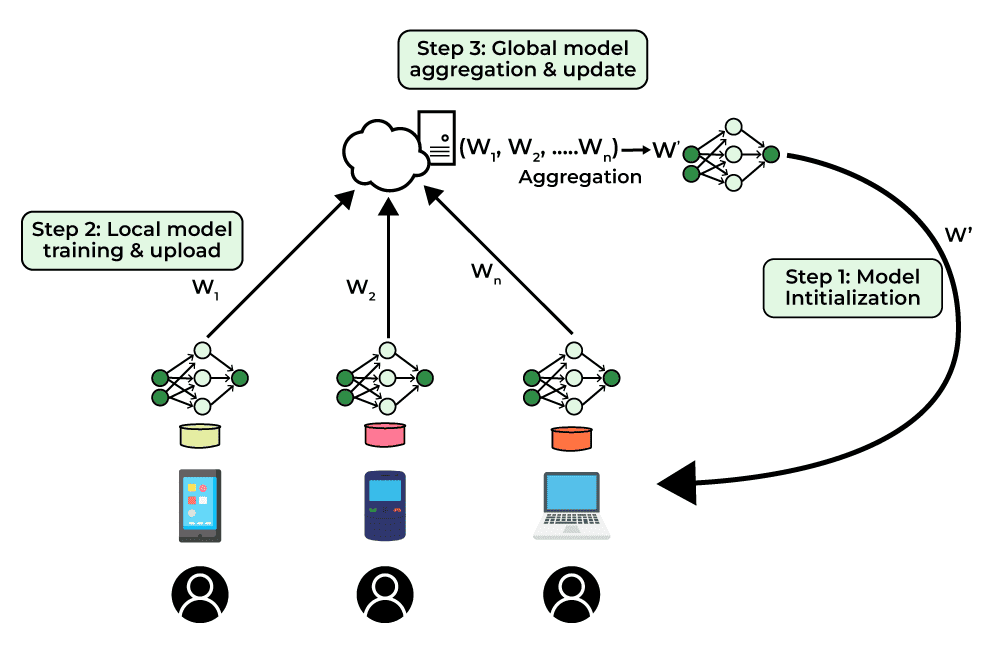


### 2. Why inspect data readiness before training?

In federated learning the server **never sees the client data**, so a silent data problem on one client (severe class imbalance, duplicated samples, corrupted/noisy images, outliers) shows up only as a mysteriously bad global model. *AI data readiness inspection* solves this by having each client compute quantitative readiness metrics **locally** and report only those aggregate numbers and plots to the server — the raw data never leaves the client.

APPFL's data readiness support follows the [AI Data Readiness Inspector (AIDRIN)](https://dl.acm.org/doi/pdf/10.1145/3676288.3676296) methodology:

> K. Hiniduma, S. Byna, J. L. Bez, and R. Madduri. *"AI Data Readiness Inspector (AIDRIN) for Quantitative Assessment of Data Readiness for AI"*, SSDBM 2024.

It gives you two complementary things:

#### (a) Standard readiness metrics — `data_readiness_configs.dr_metrics`

A catalogue of ready-to-use metrics and plots that you switch on/off with a boolean in the server configuration file, for example:

| Metric | What it tells you |
| --- | --- |
| `class_imbalance` | How far the label distribution is from uniform (0 = perfectly balanced) |
| `sample_size` / `num_classes` | How much data and how many labels the client holds |
| `completeness` | Fraction of non-missing (non-`NaN`) values |
| `sparsity` | Fraction of exactly-zero values |
| `variance`, `skewness`, `kurtosis`, `entropy` | Distributional shape of the raw features |
| `outlier_proportion` | Fraction of samples flagged as outliers |
| `brisque`, `sharpness`, `total_variation` | No-reference image quality scores |
| `plot.*` | Class-distribution pie chart, sample grid, pixel-value density, class-wise variance, ... |

#### (b) CADRE modules — `dr_metrics.cadremodule_configs`

**CADRE** (**C**ustomizable **A**ssurance of **D**ata **RE**adiness) modules let you go beyond reporting and actually *fix* a problem. A CADRE module subclasses `appfl.misc.data_readiness.BaseCADREModule` and implements three methods:

- `metric()` — compute a custom, domain-specific readiness number for the local dataset.
- `rule(metric_result)` — decide whether that number is bad enough to act on.
- `remedy(metric_result, logger)` — return an "AI-ready" version of the dataset (undersample the majority class, drop duplicates, filter outliers, ...).

APPFL ships five example CADRE modules for MNIST in `./resources/configs/mnist_dr/cadre_module/`:

| File | Class | Issue handled |
| --- | --- | --- |
| `handle_ci.py` | `CADREModuleCI` | Class imbalance (undersamples the majority class) |
| `handle_duplicates.py` | `CADREModuleDuplicates` | Duplicate samples |
| `handle_noise.py` | `CADREModuleNoise` | Noisy samples |
| `handle_outliers.py` | `CADREModuleOutliers` | Outliers (IQR on per-image mean/std) |
| `handle_mem.py` | `CADREModuleMem` | Excessive memory footprint |

Setting `remedy_action: true` tells the client to run `remedy()` and train on the repaired dataset; with `remedy_action: false` the module only reports.

#### What this tutorial does

This tutorial uses the **binary** version of MNIST (digits `0-4` → class `0`, digits `5-9` → class `1`) partitioned across two clients with a `class_noniid` strategy, so each client ends up with a **different and deliberately imbalanced** class ratio. We use `CADREModuleCI` with `remedy_action: true`, so each client will:

1. Measure its own readiness metrics,
2. Detect the class imbalance and rebalance its local dataset,
3. Send the resulting report to the server, which merges the two clients' reports into a single HTML file,
4. Train the global model on the repaired (AI-ready) data.


### 3. Create the federated learning client agent from configurations

We need to update the `server_uri` to the address obtained from the **server** notebook.

#### Steps:

- ##### Obtain the `server` address:
  - For example, the server address printed by the server notebook might be `172.31.79.131:50051`.

- ##### Update the code:
  - Replace the placeholder in the following line with the actual address you obtained:

  - `client_agent_config.comm_configs.grpc_configs["server_uri"] = "172.31.79.131:50051"`

The client configuration has four main parts:

- `client_id`: A unique identifier for this client (`Client2`)
- `train_configs`: Client-specific training-related configurations, such as the device and logging directories
- `data_configs`: Information about the dataloader file that creates the PyTorch datasets for this client's MNIST partition
- `comm_configs`: Information needed to connect to the server notebook

Note that the client configuration says **nothing** about data readiness — the readiness metrics and the CADRE module to use are decided centrally by the server and shipped to every client in step 5.


In [ ]:
from omegaconf import OmegaConf
from appfl.agent import ClientAgent

client_agent_config = OmegaConf.load(
    "./resources/configs/mnist_dr/client_2_cadremodule.yaml"
)
client_agent_config.comm_configs.grpc_configs["server_uri"] = (
    "sci-XXX-grpc.trac.appflx.link"  # Reminder: Replace this with the URI you got from the web interface.
)
client_agent_config.comm_configs.grpc_configs["use_ssl"] = True
print("==========Client Configuration==========")
print(OmegaConf.to_yaml(client_agent_config))
print("========================================")

W0824 10:58:37.291000 65350 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


==========Client Configuration==========
client_id: Client2
train_configs:
  device: cpu
  logging_output_dirname: ./output
  logging_output_filename: result
data_configs:
  dataset_path: ./resources/dataset/mnist_dataset_dr.py
  dataset_name: get_mnist
  dataset_kwargs:
    num_clients: 2
    client_id: 1
    partition_strategy: class_noniid
    visualization: true
    output_dirname: ./output
    output_filename: visualization.pdf
comm_configs:
  grpc_configs:
    server_uri: localhost:50051
    max_message_size: 10485760
    use_ssl: false



Below is the content of the client dataset definition file. It turns MNIST into a **binary** classification task (digits `0-4` → class `0`, digits `5-9` → class `1`) and partitions it across the clients using `class_noniid_partition_binary`, which gives each client a *different, randomly imbalanced* class ratio — exactly the kind of data readiness issue this tutorial detects and fixes.

The file also shows how to deliberately inject other data issues with `add_noise_to_subset` and `add_duplicates` from `appfl.misc.data_readiness.data_pollute`, which is useful when you want to exercise the noise / duplicate / outlier CADRE modules on an otherwise very clean dataset like MNIST.

If you are using your own dataset, modify the `data_configs` part accordingly: provide your own definition file path as `dataset_path`, the name of the definition function as `dataset_name`, and any additional arguments for that function in `dataset_kwargs`. The dataset function must return two PyTorch dataset objects, one for training and one for validation.


In [4]:
print("============Client Dataset==============")
with open(client_agent_config.data_configs.dataset_path, "r") as f:
    print(f.read())
print("========================================")

============Client Dataset==============
import os
import torch
import torchvision
from omegaconf import OmegaConf
import torchvision.transforms as transforms
from appfl.misc.data import (
    Dataset,
    iid_partition,
    class_noniid_partition_binary,
    dirichlet_noniid_partition,
)
from appfl.misc.data_readiness.data_pollute import add_noise_to_subset, add_duplicates


def get_mnist(
    num_clients: int, client_id: int, partition_strategy: str = "iid", **kwargs
):
    """
    Return the MNIST dataset for a given client.
    :param num_clients: total number of clients
    :param client_id: the client id
    """
    # Get the download directory for dataset
    dir = os.getcwd() + "/datasets/RawData"
    server_agent_config = OmegaConf.load(
        "./resources/configs/mnist_dr/server_fedavg_cadremodule.yaml"
    )

    # Load the server agent config to get the pollution method based on the CADFEModule name
    if hasattr(server_agent_config, "data_readiness_configs") and hasattr

In [5]:
# Create the client agent (this loads the local dataset)
client_agent = ClientAgent(client_agent_config=client_agent_config)

print(f"Client ID           : {client_agent.get_id()}")
print(f"Local training size : {client_agent.get_sample_size()}")

appfl: ✅[2026-08-24 10:58:41,533 Client2]: Logging to ./output/result_Client2_2026-08-24-10-58-41.txt


Client ID           : Client2
Local training size : 29947


### 4. Create the client communicator

Now, we create a gRPC client communicator for sending various requests to the server. There are five types of request used in this notebook:

(1) `get_configuration()`: Get the general client configurations (training settings, model, **and the data readiness configuration**) from the server

(2) `get_global_model(init_model=True)`: Get the initial global model for training

(3) `update_global_model()`: Send the trained local model to update the global model, and get the updated model back for further local training

(4) `invoke_custom_action(action=...)`: Perform a custom action — here `set_sample_size`, `get_data_readiness_report`, and `close_connection`

(5) `invoke_custom_action(action="close_connection")`: Close the connection with the server


In [6]:
from appfl.comm.grpc import GRPCClientCommunicator

client_communicator = GRPCClientCommunicator(
    client_id=client_agent.get_id(),
    logger=client_agent.logger,
    **client_agent_config.comm_configs.grpc_configs,
)

### 5. Get the readiness configuration from the server

The server decides which readiness metrics every client should compute and which CADRE module to apply, so the first thing we do is fetch that configuration.


In [7]:
client_config = client_communicator.get_configuration()

print("=======Data Readiness Configuration (from server)=======")
print(OmegaConf.to_yaml(client_config.data_readiness_configs))
print("=======================================================")

cadremodule_configs = (
    client_config.data_readiness_configs.dr_metrics.cadremodule_configs
)
print(f"============CADRE Module: {cadremodule_configs.cadremodule_path}============")
with open(cadremodule_configs.cadremodule_path, "r") as f:
    print(f.read())
print("=========================================================")

=======Data Readiness Configuration (from server)=======
dr_metrics:
  brisque: false
  cadremodule_configs:
    cadremodule_name: CADREModuleCI
    cadremodule_path: ./resources/configs/mnist_dr/cadre_module/handle_ci.py
    remedy_action: true
  class_distribution: true
  class_imbalance: true
  combine:
    feature_space_distribution: false
  completeness: true
  data_range: false
  data_shape: false
  entropy: false
  kurtosis: false
  num_classes: true
  outlier_propotion: false
  plot:
    class_distribution_plot: true
    class_variance_plot: true
    data_distribution_plot: false
    data_sample_plot: true
  sample_size: true
  sharpness: false
  skewness: false
  sparsity: true
  total_variation: false
  variance: true
generate_dr_report: true
output_dirname: ./notebook_tutorials/mnist_aidrin_nersc/output
output_filename: data_readiness_report

============CADRE Module: ./resources/configs/mnist_dr/cadre_module/handle_ci.py============
import torch
import random
import numpy a

### 6. Inspect the local dataset **before** any remedy

`client_agent.generate_readiness_report(client_config)` computes every metric enabled by the server on this client's local training set, and returns a dictionary of:

- scalar metrics (`sample_size`, `class_imbalance`, `completeness`, ...),
- base64-encoded PNG plots under the `plots` key,
- the CADRE module's own custom metric under the `specified_metrics` key.

Everything is computed **locally** — only this dictionary would ever be sent to the server. Let's look at it before we repair anything.


================ BEFORE remedy ================
         class_imbalance: 0.09
             sample_size: 29947
             num_classes: 2
            completeness: 1.0
                variance: 0.09
      class_distribution: {0: 13058, 1: 16889}
     CADRE module metric: {'class_imbalance': 0.13}
      input tensor shape: (1, 28, 28)

[class_distribution_plot]


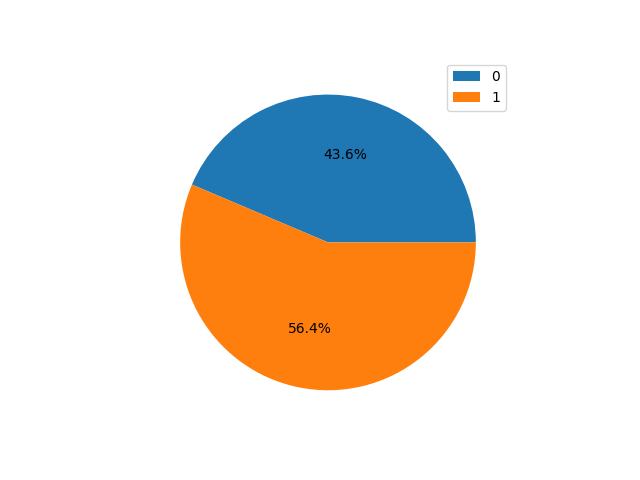


[data_sample_plot]


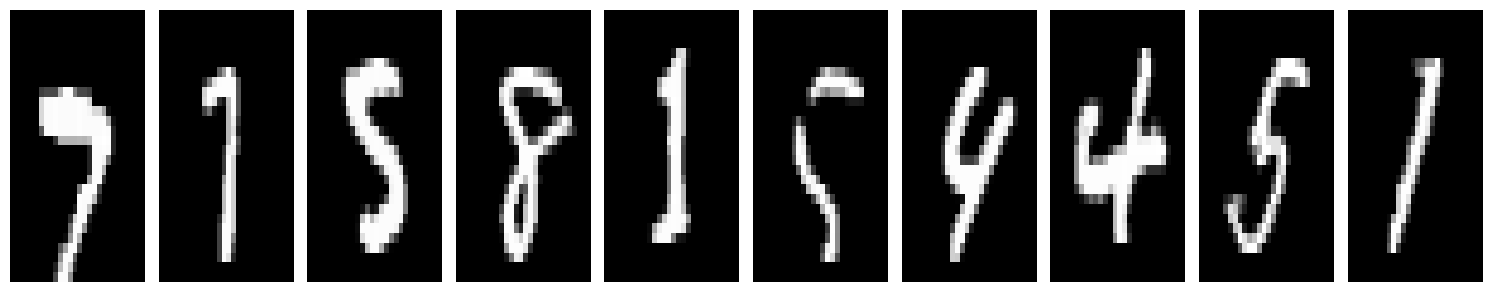


[class_variance_plot]


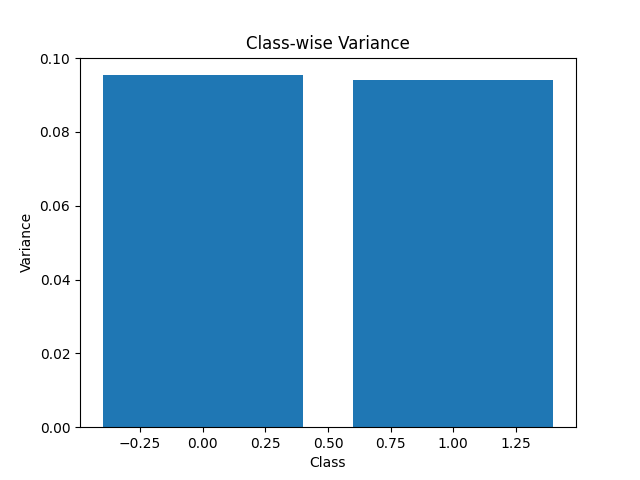

In [8]:
import base64
from IPython.display import Image, display


def show_report(report, title):
    print(f"================ {title} ================")
    for key, value in report.items():
        if key in ("plots", "to_combine", "specified_metrics"):
            continue
        print(f"  {key:>22}: {value}")
    if report.get("specified_metrics"):
        print(f"  {'CADRE module metric':>22}: {report['specified_metrics']}")
    input_shape = tuple(client_agent.train_dataset[0][0].shape)
    print(f"  {'input tensor shape':>22}: {input_shape}")
    print("=" * (34 + len(title)))
    for plot_name, encoded in report.get("plots", {}).items():
        print(f"\n[{plot_name}]")
        display(Image(data=base64.b64decode(encoded)))


report_before = client_agent.generate_readiness_report(client_config)
show_report(report_before, "BEFORE remedy")

### 7. Apply the CADRE module remedy

If the server set `remedy_action: true`, we call `client_agent.adapt_data(client_config)`. This instantiates the CADRE module on the local dataset and runs `remedy(metric(), logger)`; for `CADREModuleCI` that means undersampling the majority class until both classes have the same number of samples. `client_agent.train_dataset` is then replaced by the returned AI-ready dataset.

> 💡 **Ordering matters.** We run the remedy *before* `client_agent.load_config(...)`, because `load_config` is what builds the local trainer — and the trainer captures a reference to `client_agent.train_dataset` at construction time. Repairing the data first guarantees that training actually uses the AI-ready dataset.


In [9]:
remedy_action = cadremodule_configs.get("remedy_action", False)

if remedy_action:
    size_before = client_agent.get_sample_size()
    client_agent.adapt_data(client_config)
    size_after = client_agent.get_sample_size()
    print(f"CADRE remedy applied: {size_before} -> {size_after} local training samples")
else:
    print(
        "remedy_action is False: reporting only, the local dataset is left untouched."
    )

appfl: ✅[2026-08-24 10:58:47,247 Client2]: Dataset modified: Majority class undersampled to balance class distribution.


CADRE remedy applied: 29947 -> 26116 local training samples


================ AFTER remedy ================
         class_imbalance: 0.0
             sample_size: 26116
             num_classes: 2
            completeness: 1.0
                variance: 0.09
      class_distribution: {0: 13058, 1: 13058}
     CADRE module metric: {'class_imbalance': 0.0}
      input tensor shape: (1, 28, 28)

[class_distribution_plot]


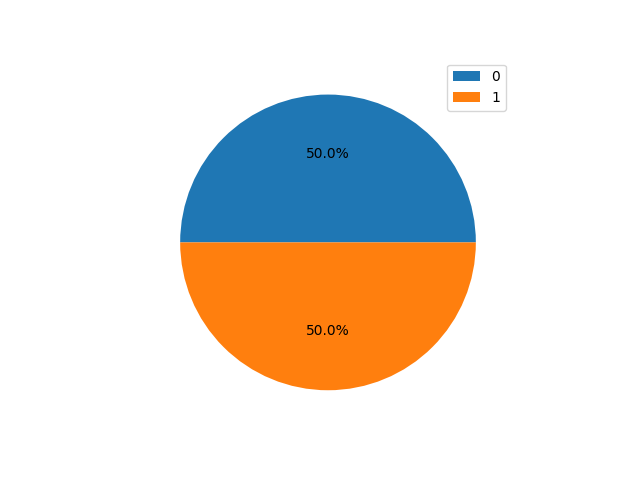


[data_sample_plot]


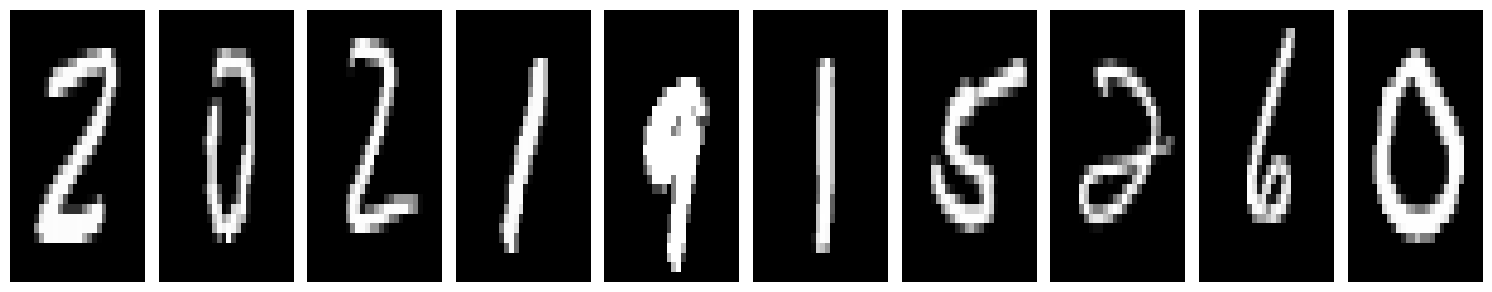


[class_variance_plot]


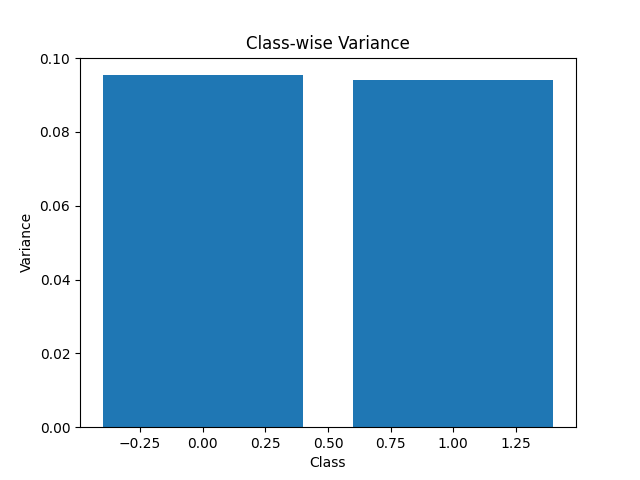

In [10]:
report_after = client_agent.generate_readiness_report(client_config)
show_report(report_after, "AFTER remedy")

### 8. Send the readiness report to the server

The report is sent through the `get_data_readiness_report` custom action. The server buffers the reports from all clients and, once the last one arrives, merges them into a single HTML dashboard under its `./output/` directory.

> ⏳ This cell **blocks until every client has sent its report** (the server keeps the request open for synchronization). If it seems to hang, make sure the other client notebook has also reached this point.


In [11]:
# Tell the server how many samples this client holds (used for weighted aggregation)
client_communicator.invoke_custom_action(
    action="set_sample_size", sample_size=client_agent.get_sample_size()
)

# Send the data readiness report (blocks until all clients have reported)
client_communicator.invoke_custom_action(
    action="get_data_readiness_report", **report_after
)
print("✅ Data readiness report sent. The merged HTML report is written by the server.")

✅ Data readiness report sent. The merged HTML report is written by the server.


### 9. Start the training loop

Now that the local dataset is AI-ready, we load the training configuration from the server (which builds the local trainer on the repaired dataset), fetch the initial global model, and run the federated training loop:

1. Train locally for `num_local_steps` steps.
2. Send the local model to the server with `update_global_model()` and receive the updated global model.
3. Repeat until the server reports `status == "DONE"`.
4. Close the connection.

You will see the validation accuracy and loss printed at every round.


In [12]:
# Load the server-provided training configuration -> builds the trainer on the AI-ready dataset
client_agent.load_config(client_config)

# Get the initial global model parameters
init_global_model = client_communicator.get_global_model(init_model=True)
if isinstance(init_global_model, tuple):
    init_global_model, metadata = init_global_model
else:
    metadata = {}
client_agent.load_parameters(init_global_model)

In [13]:
# Start the local training loop
while True:
    client_agent.train(**metadata)
    local_model = client_agent.get_parameters()
    if isinstance(local_model, tuple):
        local_model, metadata = local_model
    else:
        metadata = {}
    new_global_model, metadata = client_communicator.update_global_model(
        local_model, **metadata
    )
    if metadata["status"] == "DONE":
        break
    if "local_steps" in metadata:
        client_agent.trainer.train_configs.num_local_steps = metadata["local_steps"]
    client_agent.load_parameters(new_global_model)

# Close the connection
client_communicator.invoke_custom_action(action="close_connection")
print("✅ Federated learning finished.")

appfl: ✅[2026-08-24 10:58:48,656 Client2]:      Round   Pre Val?       Time Train Loss Train Accuracy   Val Loss Val Accuracy
appfl: ✅[2026-08-24 10:58:49,788 Client2]:          0          Y                                          0.6932      51.3900
appfl: ✅[2026-08-24 10:58:53,135 Client2]:          0          N     3.3460     0.0697        87.1250     0.1280      95.6400
appfl: ✅[2026-08-24 10:58:58,375 Client2]:          1          Y                                          0.1408      95.7500
appfl: ✅[2026-08-24 10:59:01,696 Client2]:          1          N     3.3189     0.0229        96.4688     0.0884      97.0100
appfl: ✅[2026-08-24 10:59:06,991 Client2]:          2          Y                                          0.0749      97.2400
appfl: ✅[2026-08-24 10:59:10,408 Client2]:          2          N     3.4155     0.0174        97.2812     0.0655      97.4900
appfl: ✅[2026-08-24 10:59:15,599 Client2]:          3          Y                                          0.0541      

✅ Federated learning finished.


### 10. What to look at next

Go back to the **server** notebook and run its last section to render the merged data readiness report, which puts both clients' metrics and plots side by side — this is the view that lets a federation organizer spot a problematic site without ever seeing its data.
